TP-10-Skill-Reservation

3. Gestionnaire de ressources 

Quel est le nom du gestionnaire de resources de la plateforme Grid'5000?

In [ ]:
Le nom du gestionnaire de ressources est OAR

Quelle est la commande permettant d’effectuer une réservation de resources?

In [ ]:
Oarsub -I

Quelle est la différence entre les options “-I” et “-t”?

In [ ]:
-I est le mode interactif, permettant de communiquer avec le node, -t permet une configuration plus spécifique du noeuds grace a plusieurs options disponible.

4. Réserver un nœud en mode interactif 

In [ ]:
Réservez un nœud de calcul en mode interactif pendant une heure : oarsub -I walltime = 1:00:00

Que se passe-t-il après l’exécution de la commande ? 

OAR filtre les ressources exotique, set le walltime et allouer un noeud avec un ID unique, permettant de se connecter a une machine en mode interactif

Comment afficher les détails de la réservation ? 

lscpu

5. Réserver un nœud spécifique 

Ecrire la commande permettant de réserver 2 noeuds sur le site de nantes pendant 20 minutes : ssh nantes - oarsub -l nodes=2 ,walltime=0:20 -I

Que signifie l’option -p ? L'option -p permet de choisir un cluster précis "-p taurus"

Que se passe-t-il si le cluster est mal orthographié ? Bad resource request (ERROR:  column "econom" does not exist

Que fait la commande oarstat -u ? Elle donne la liste des job en cours d'utilisation

6. Réservation avec un script de job

Soumettre le job en réservant un noeud pendant 10 minutes sur le site de rennes : ssh rennes - oarsub -l walltime=0:10 -I (mais sortie dans le terminal) ou  	
oarsub -l walltime=0:10 "./mon_script.sh"

Où est redirigée la sortie du script ? Dans le terminal si en mode -I ou dans les fichier OAR..stdout

In [ ]:
Que contiennent les fichiers OAR..stdout et OAR..stderr ? Le stdout contient la sortie du programme .sh et le stderr donne : /var/lib/oar/.batch_job_bashrc: line 5: /home/cchiaber/.bashrc: No such file or directory

In [ ]:
Que se passe-t-il si le script plante ? Il n'y a pas de fichier OAR..stdout et OAR..stderr de créer

TP-11-Skill-NodeJS

2. Exécution de la page Hello World

In [ ]:
cchiaber@econome-22:~/public/TP-10_11$ node hello-world.js
Hello from the class => 'Middleware 2024'
Hello again from the class => Middleware 2024
constItem => 10

letItem => I love coffee with 2 slices of blueberry cake !
letItem => I love coffee with 3 slices of blueberry cake !
letItem => I love coffee with 4 slices of blueberry cake !

varItem => I love to drive but only up to 1.5 hours and 1 second !
varItem => I love to drive but only up to 2 minutes !
varItem => I love to drive but only up to 3 minutes !
varItem => I love to drive but only up to 4 minutes !
varItem => I love to drive but only up to 5.5 hours and 1 second !

3. Installation des packages Node.js ET Exécutez le script principal pour démarrer le serveur :

In [ ]:
cchiaber@econome-22:~/public/TP-10_11$ node main-express-static.js
Listening to 172.16.192.22:3000 !!!

4. Redirection du port 3000 vers votre machine locale 

In [ ]:
cchiaber@fnantes:/$ ssh -NL 3000:172.16.192.22:3000 cchiaber@access.grid5000.fr
Warning: Permanently added 'access.grid5000.fr' (ED25519) to the list of known hosts.
bind [127.0.0.1]:3000: Address already in use
channel_setup_fwd_listener_tcpip: cannot listen to port: 3000
Could not request local forwarding.


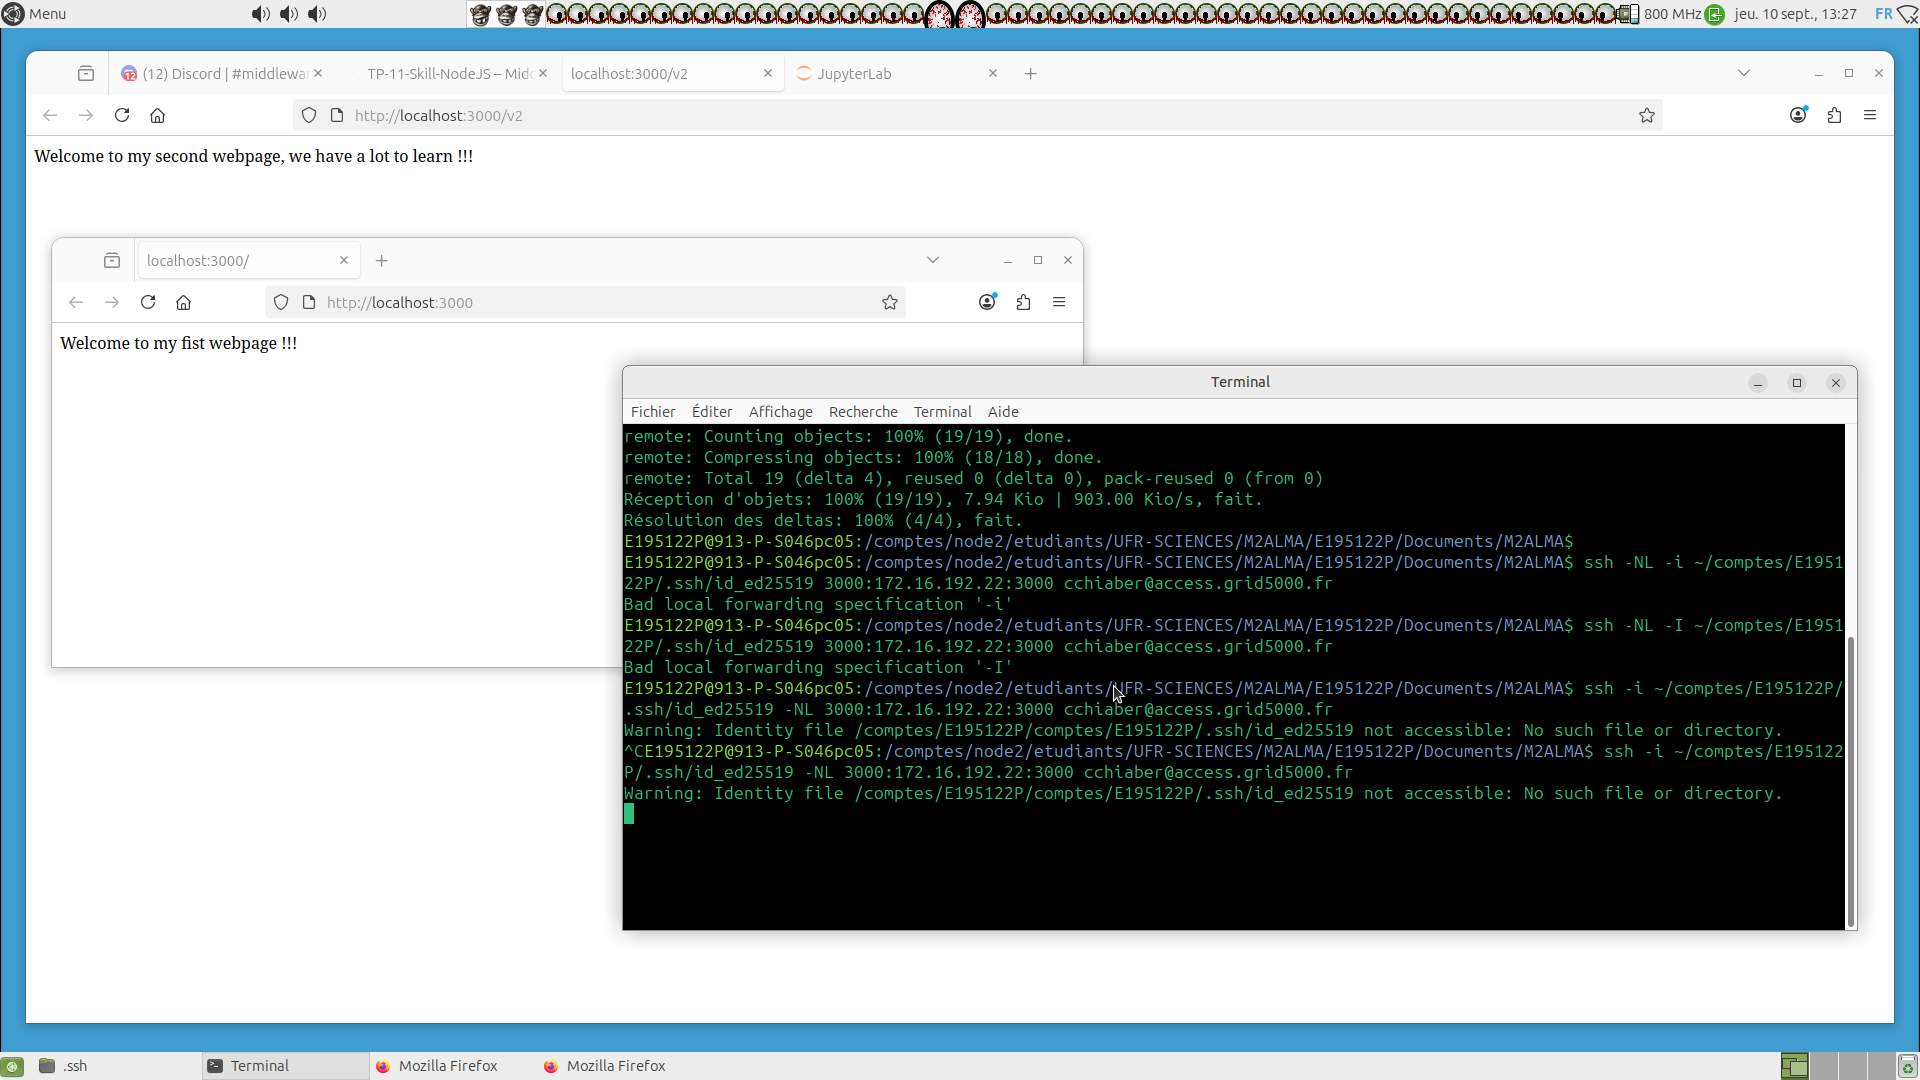

main-data-generator est un petit serveur qui écoute le port 3000, configure la génération, génére les données aléatoires et les stocke, attend et répond au requetes GET/POST via HTML/JSON.
test-data-generator se comporte comme un client et envoie des requetes POST au serveur. 

Quels sont les rôles des paquets express, ip, clone, ejs et axios ? 

express : Est ici un framework Nodes.js permettant de simplifier la communication HTTP (les routes, les vues ect...), partie Serveur
ip : Permet de récupérer l'adresse IP locale
clone : Permet de faire une copie profonde d'un objet JavaScript
ejs : Permet de générer du HTML
axios : (Dans test-data-generator) Permet d'envoyer des requêtes HTTP, partie Client

Quelles sont les différentes commandes effectuées par le fichier de test ?

Les commandes effectués sont des requêtes AJAX.

Setting : Permet de choisir le type de generation 
DeleteAllData : Vide l'historique des données
Start : Démarre la génération 
Stop : Stop la génération
Fetch-Data : Récupère toutes les données générées entre le Start et le Stop


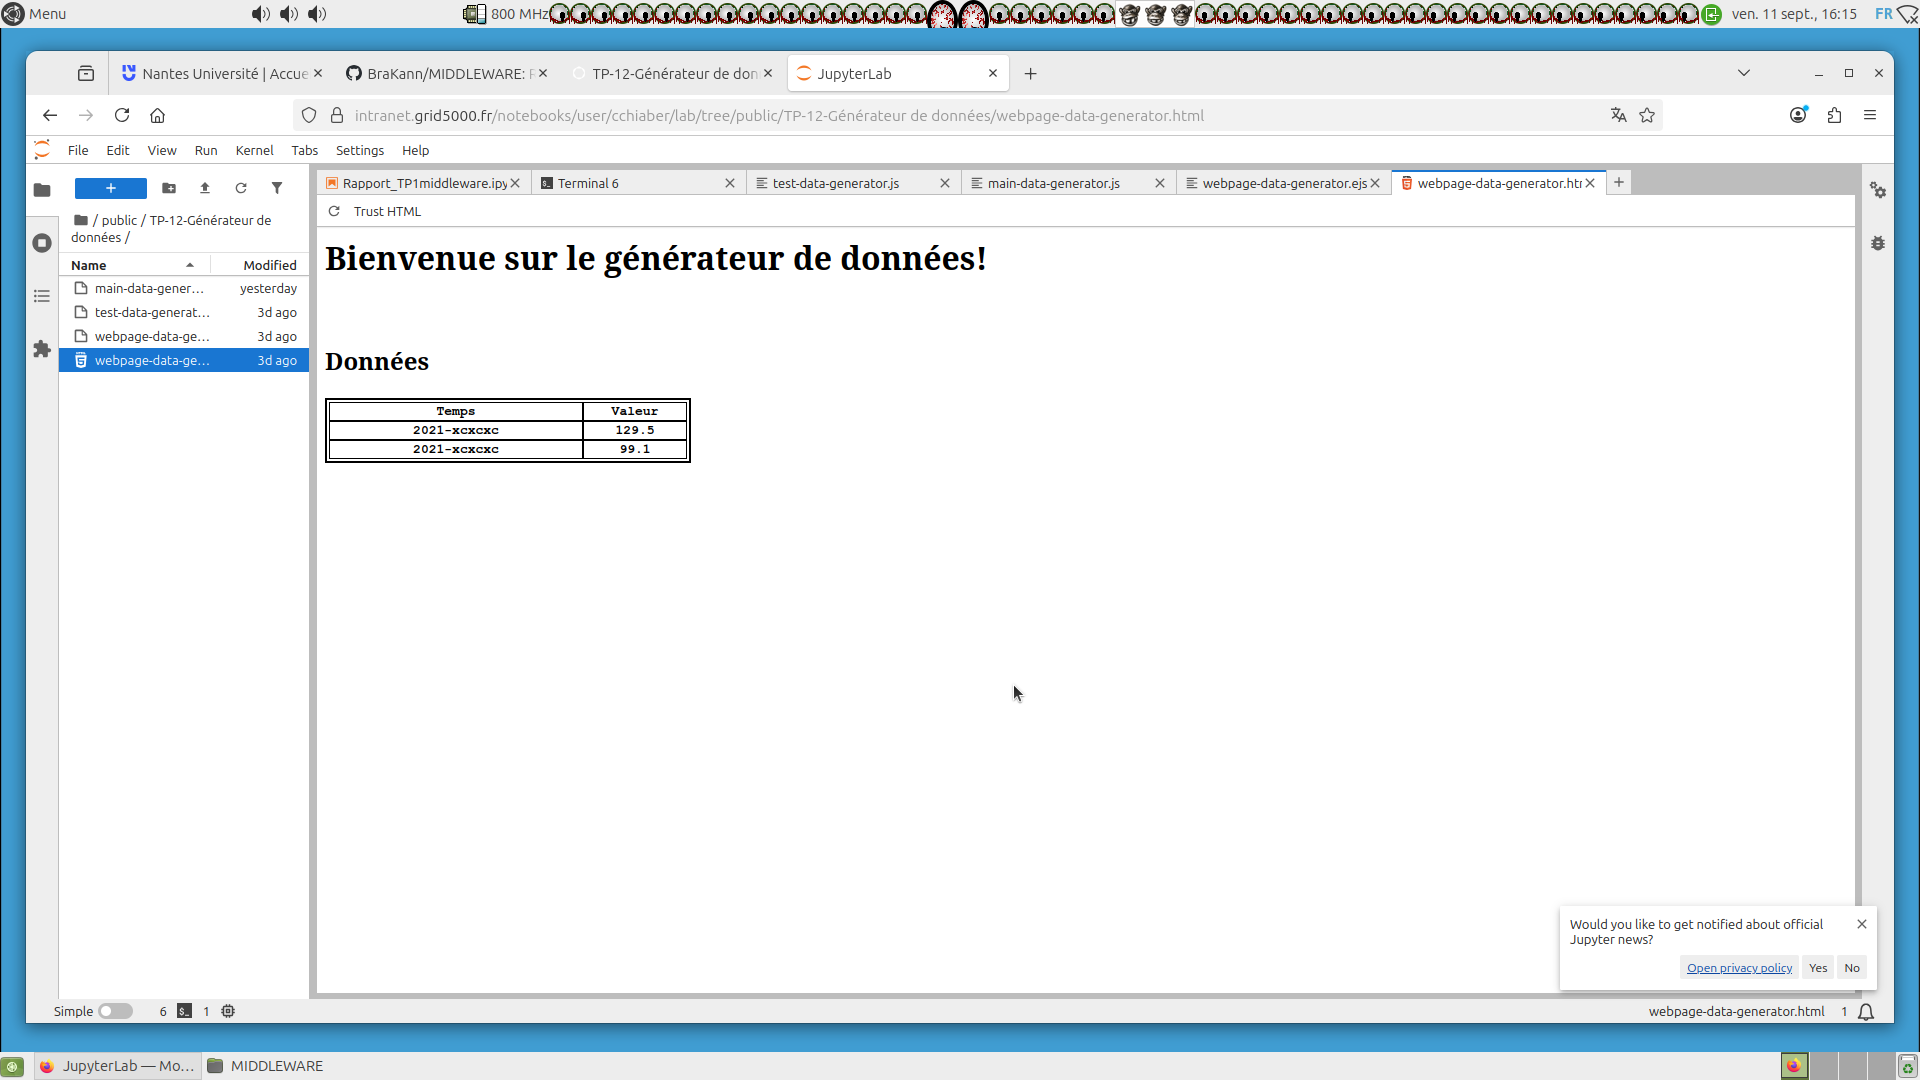

Ouvrez le fichier <webpage-data-generator.ejs>, pour en comparer le contenu avec <webpage-data-generator.html>.

Le contenue qu'on retrouve dans le .html est bien celui attendu apres execution du .ejs

On y retroue le meme template, les memes informations (titre : "<h1>Bienvenue sur le générateur de données!</h1>", tableau : "<h2>Données</h2> <table...")
Et les données générées et recuperées par le serveur dans le tableau par : 

"<% htmlDataPoints.forEach( dp=> { %>
            <tr>
                <th style="border-style:solid;border-width:1px;">
                    <%= dp['TimeStampFormatted'] %>
                </th>
                <th style="border-style:solid;border-width:1px;">
                    <%= dp['DataValue'] %>
                </th>

                <% }) %>
            </tr>"

In [ ]:
cchiaber@econome-8:~/public/TP-12-Générateur de données$ node main-data-generator.js 
Listening to 172.16.192.8:3000 !!!

In [ ]:
cchiaber@econome-8:~/public/TP-12-Générateur de données$ node test-data-generator.js 
{ Message: 'Config/Update: ' }
{ Message: 'Execute:DeleteAllData' }
{ Message: 'Execute:Start' }
{ Message: 'Execute:Stop' }
[
  {
    TimeStampRaw: '2026-09-11T14:47:40.637Z',
    TimeStampFormatted: '2026-09-11 16:47:40.637',
    DataValue: 0
  }
]

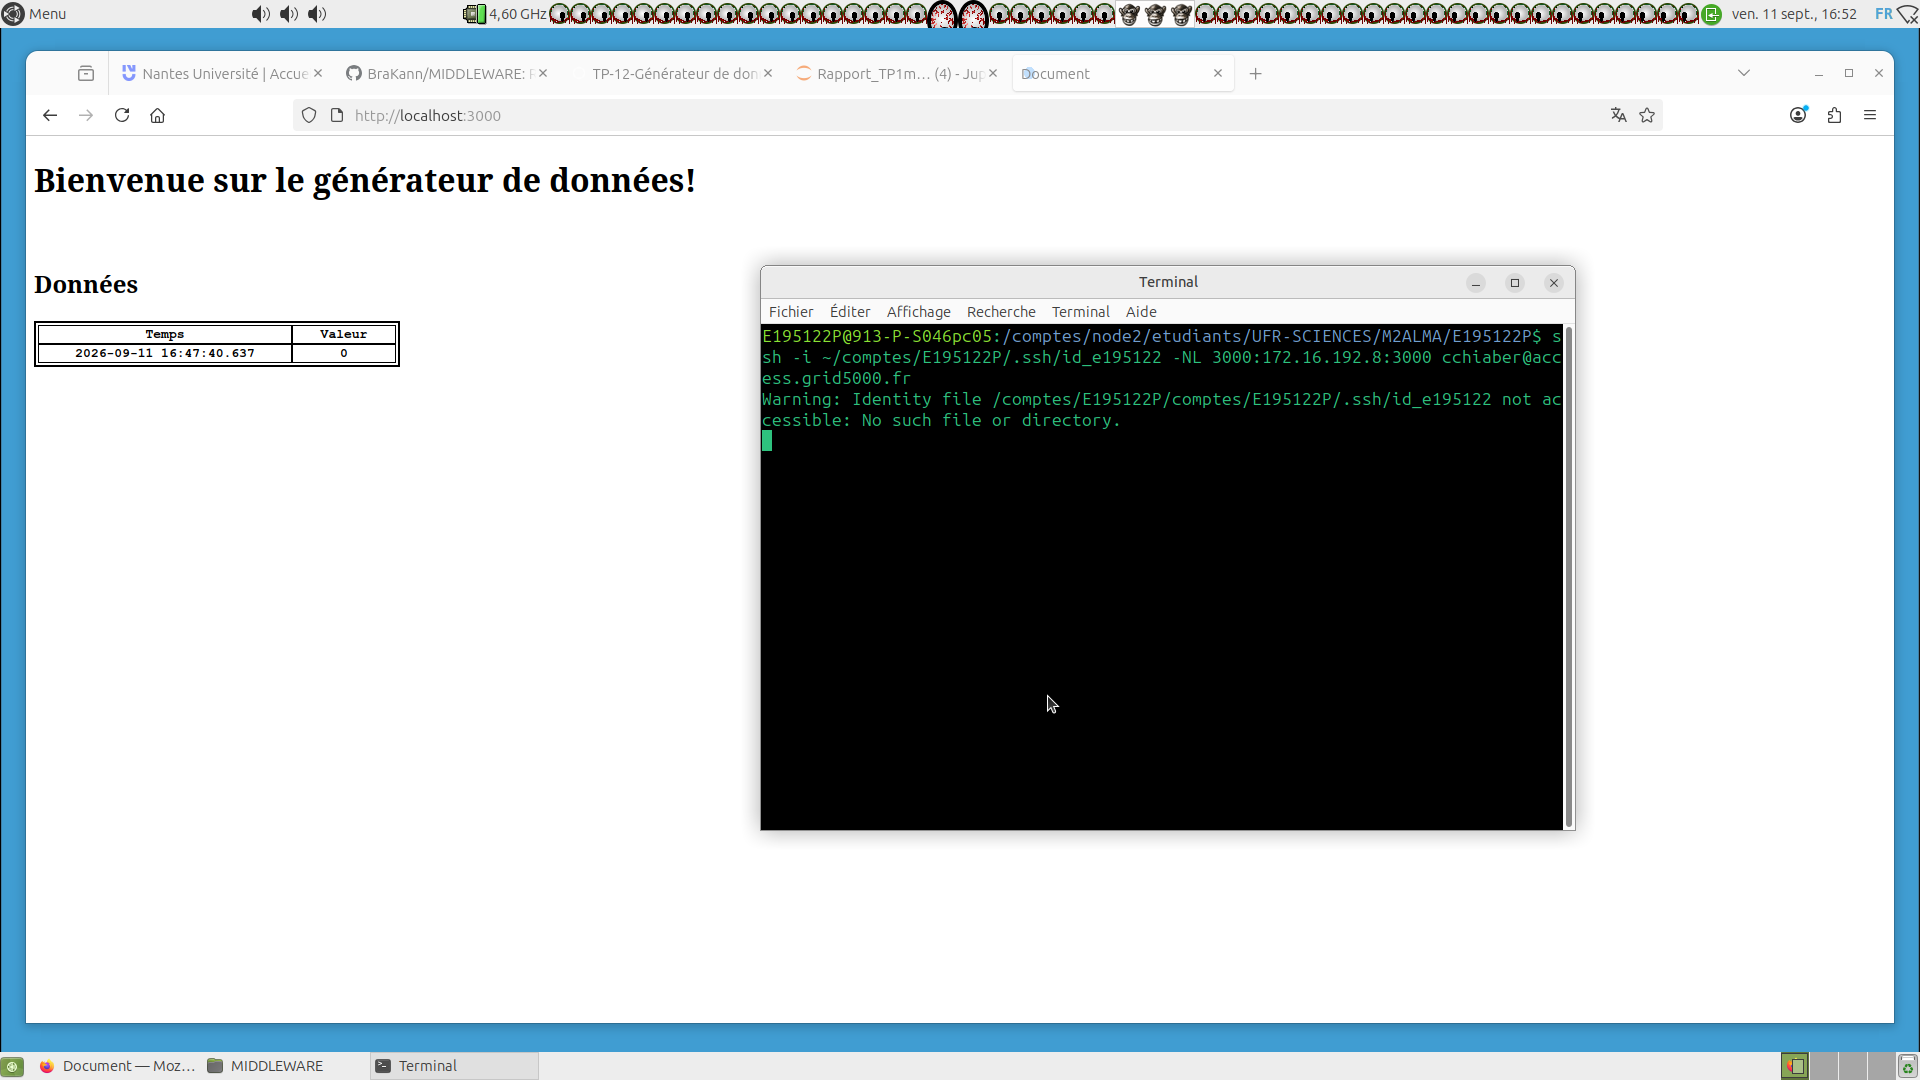

Etant donner que les algorithme de generation ne sont pas ecrit, ils retournent 0.

## Tache

Compléter le fichier <main-data-generator.js> pour

    générer des nombres aléatoires selon deux distributions (uniforme et normale) (lignes 58 à 66)
    permettre un affichage à l’aide des commandes Start, Stop et DeleteAll (lignes 75 à 97)


## RAPPORT

Mise en place des methodes de destibutions des données.

Pour la distribution uniforme, chaque valeur a exactement la même probabilité d'etre générée.
Soit, Params: { min: -10, max: 10 }

Pour la distribution normale, elle est centrée autour d'une moyenne (mu), avec un écart-type (sigma) qui contrôle la dispersion des valeurs autour de mu.
Soit Params: { mu: 100, sigma: 10 }

L'intervalle de temps entre les deux générations restera le meme pour les deux type de génération.

Le package random implemente deja ces distibution : random.uniform(min, max) et random.normal(mu, sigma)

Les parametres min, max et mu, sigma peuvent etre recuperer via params, qui depend du DistributionType appliqué apres la command Setting donc récuperable dans le JSON generé.

